**HVG selection study | catnap_core** ᓚᘏᗢ
-----

Whether catnap's per-node HVG re-selection differs from a single global selection, and whether the
difference changes downstream accuracy.  
Check `README.md` for notations and full experiment list.

Output: figures to `figures/<dataset>/`, tables to `tables/`, scores to `results/`, models to `runs/`.

| key | $a$ | $b$ |
|---|---|---|
| **F-NR** / **KW-NR** | node, children cut | root, leaf cut |
| **F-NN** / **KW-NN** | node | another node outside its subtree |
| **F-CL** / **KW-CL** | node, children cut | node, leaf cut |
| **VST($v$)-NR** | node, refitted LOESS | root |
| **VST($v_0$)-NR** | node, root LOESS | root |
| **VST($v_0$)-NN** | node, root LOESS | another node outside its subtree, root LOESS |

In [3]:
# --- IMPORTS ---
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

sys.path.insert(0, str(Path.cwd()))   # hvgsel/ sits next to this notebook
try:
    import catnap_core
except ModuleNotFoundError:
    raise RuntimeError("catnap_core not importable: `pip install -e` the catnap_core repo "
                       "into this environment, see README.md")

from catnap_core.utils import set_verbosity

from hvgsel import (ALL_NN, Score, Scorer, cl, keys_for, load_dataset, node_vs_node,
                    node_vs_root, plots, report, runs)
from hvgsel import datasets   # via the module, so %autoreload picks up edits to DATASETS

set_verbosity(0)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# --- SETUP ---
DATASET   = "aifi"     # "aifi" | "hao"
N_TOP     = 2000
MAX_CELLS = None       # stratified cap, None -> every cell

DS = datasets.DATASETS[DATASET]
EX = DS.examples
FIG = Path("figures") / DATASET
TEX = Path("tables") / DATASET
LEVELS = [f"L{k}" for k in range(1, len(DS.label_cols) + 1)]

# Which score methods a dataset can afford is DS.methods, in datasets.py
KEYS_NR    = keys_for(DS.methods)
KEYS_NN    = keys_for(DS.methods, ALL_NN)
CL_METHODS = tuple(m for m in DS.methods if m != "vst")   # only for supervised methods
SUMMARY_LEVELS = [0]   # L1 only, range(len(DS.label_cols) - 1) for every level

adata = load_dataset(DATASET, max_cells=MAX_CELLS)
scorer = Scorer(adata, DS.label_cols, results="results", dataset=DATASET, n_top=N_TOP,
                params={"kw": {"gene_block": 128}})   # bounds the memory of a KW pass, not its result
print(f"{DS.label_cols} | scores in {scorer.store.dir} | methods {KEYS_NR}")

slug = lambda *parts: "_".join(str(p).replace(" ", "_") for p in parts)

**Parity:** top-$n$ HVGs of each score vector against what `select_hvgs` returns, on the same cells.

In [3]:
PARITY_CELLS = 50_000   # caps the number of cells, None for full dataset

for spec in [Score("f_stat", EX["nodes"][0]), Score("f_stat", "root", cut="leaves"),
             Score("kw", EX["nodes"][0]), Score("vst", EX["nodes"][0])]:
    check = scorer.parity(spec, max_cells=PARITY_CELLS)
    print(f"{check['spec']:34s} {check['n_cells']:>9,} cells  "
          f"{check['identical']}/{check['n_top']}")

F[T cell | children]                  50,000 cells  2000/2000
F[root | leaves]                      50,000 cells  2000/2000
KW[T cell | children]                 50,000 cells  2000/2000
VST[T cell | local]                   50,000 cells  2000/2000


Node vs root
------------

[F-NR] top-2000: kept 923  changed 1077 (54%)  Jaccard 0.300  Spearman 0.847  Kendall 0.692  RBO 0.108
[VST(v)-NR] top-2000: kept 792  changed 1208 (60%)  Jaccard 0.247  Spearman 0.680  Kendall 0.558  RBO 0.206
[VST(v_0)-NR] top-2000: kept 763  changed 1237 (62%)  Jaccard 0.236  Spearman 0.728  Kendall 0.641  RBO 0.212


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved -> figures/aifi/nr_T_cell.pdf


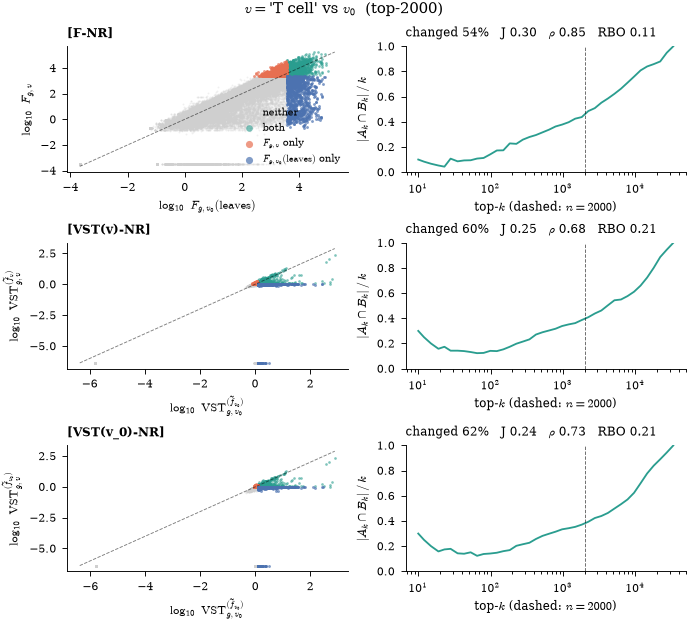

,symbol,rank[F[T cell | children]],rank[F[root | leaves]],rank_shift,selected_in
0,CPA3,28016,429,-27587,b only
1,AC097375.1,27587,284,-27303,b only
2,ERG,26980,416,-26564,b only
3,CRYGD,26840,389,-26451,b only
4,MS4A3,26887,464,-26423,b only
5,SLC12A3,27536,1499,-26037,b only
6,LINC02573,26383,368,-26015,b only
7,CYYR1,26579,1110,-25469,b only
8,KCNK10,26430,1150,-25280,b only
9,AC004540.2,25847,657,-25190,b only


[F-NR] top-2000: kept 871  changed 1129 (56%)  Jaccard 0.278  Spearman 0.803  Kendall 0.636  RBO 0.128
[VST(v)-NR] top-2000: kept 592  changed 1408 (70%)  Jaccard 0.174  Spearman 0.286  Kendall 0.245  RBO 0.053
[VST(v_0)-NR] top-2000: kept 587  changed 1413 (71%)  Jaccard 0.172  Spearman 0.323  Kendall 0.299  RBO 0.062


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved -> figures/aifi/nr_Treg.pdf


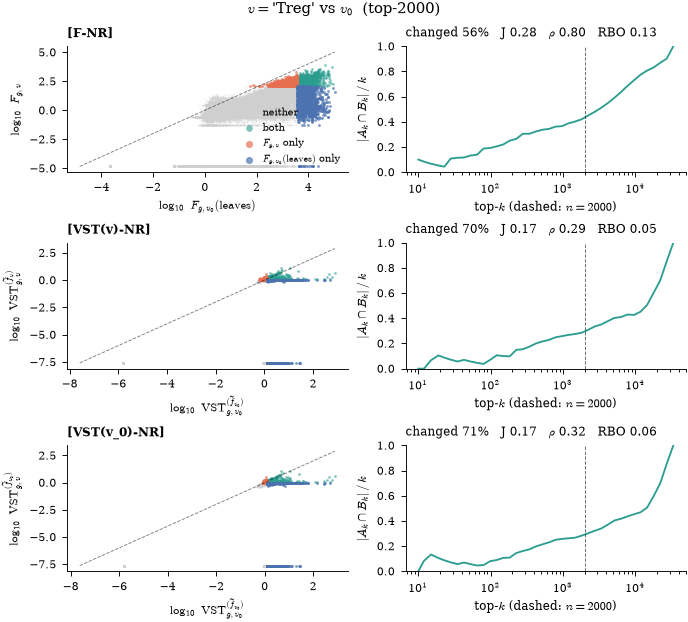

,symbol,rank[F[Treg | children]],rank[F[root | leaves]],rank_shift,selected_in
0,TPSAB1,23111,186,-22925,b only
1,LINC02573,23111,368,-22743,b only
2,TPSB2,23111,384,-22727,b only
3,MS4A3,23111,464,-22647,b only
4,BCL11A,22791,145,-22646,b only
5,CDK15,23111,558,-22553,b only
6,KIAA0087,23111,661,-22450,b only
7,P2RY13,22774,465,-22309,b only
8,AC002454.1,23111,834,-22277,b only
9,HNMT,22678,443,-22235,b only


In [5]:
for V in EX["nodes"]:
    plots.show([scorer.compare(c) for c in node_vs_root(V, KEYS_NR)],
               title=rf"$v=$'{V}' vs $v_0$  (top-{N_TOP})",
               path=FIG / f"nr_{slug(V)}.pdf")
    display(scorer.compare(node_vs_root(V, ("F-NR",))[0]).movers())

Node vs node
------------

[F-NN] top-2000: kept 690  changed 1310 (66%)  Jaccard 0.208  Spearman 0.789  Kendall 0.614  RBO 0.031
[VST(v_0)-NN] top-2000: kept 555  changed 1445 (72%)  Jaccard 0.161  Spearman 0.556  Kendall 0.474  RBO 0.089


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved -> figures/aifi/nn_Monocyte_NK_cell.pdf


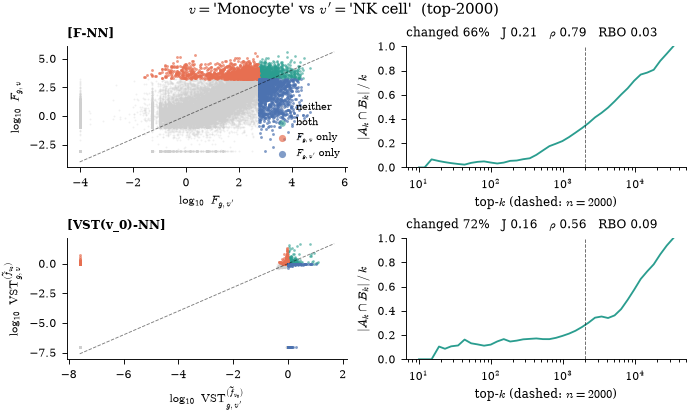

[F-NN] top-2000: kept 819  changed 1181 (59%)  Jaccard 0.257  Spearman 0.757  Kendall 0.583  RBO 0.716
[VST(v_0)-NN] top-2000: kept 987  changed 1013 (51%)  Jaccard 0.328  Spearman 0.696  Kendall 0.650  RBO 0.462


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved -> figures/aifi/nn_Naive_CD4_T_cell_Naive_CD8_T_cell.pdf


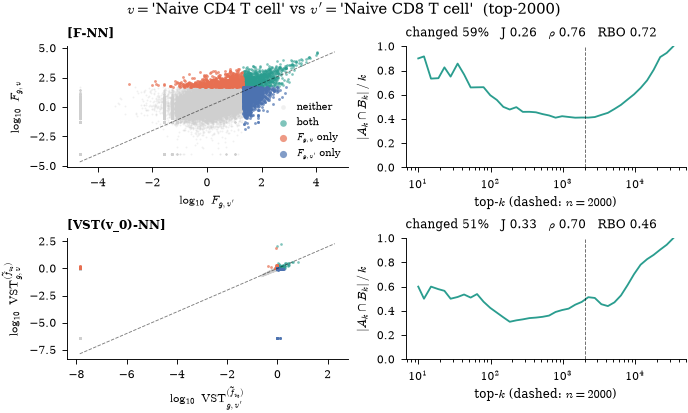

In [6]:
for V, V_PRIME in EX["pairs"]:
    plots.show([scorer.compare(c) for c in node_vs_node(V, V_PRIME, KEYS_NN)],
               title=rf"$v=$'{V}' vs $v'=$'{V_PRIME}'  (top-{N_TOP})",
               path=FIG / f"nn_{slug(V, V_PRIME)}.pdf")

Children cut vs leaf cut
------------------------

Note: needs two levels below the node.

[F-CL] top-2000: kept 1630  changed 370 (18%)  Jaccard 0.688  Spearman 0.977  Kendall 0.890  RBO 0.482


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved -> figures/aifi/cl_root.pdf


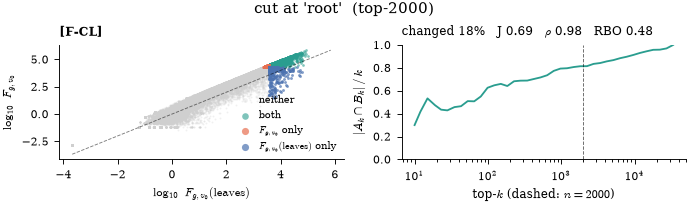

[F-CL] top-2000: kept 1872  changed 128 (6%)  Jaccard 0.880  Spearman 0.987  Kendall 0.927  RBO 0.720


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved -> figures/aifi/cl_T_cell.pdf


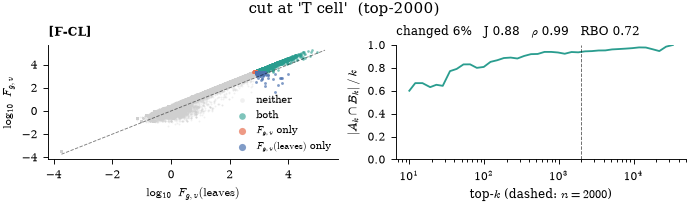

In [7]:
for V in EX["cl_nodes"]:
    plots.show([scorer.compare(cl(V, method)) for method in CL_METHODS],
               title=rf"cut at '{V}'  (top-{N_TOP})", path=FIG / f"cl_{slug(V)}.pdf")

Summary
--------------------------------

Last row of each: control, a random subset of average size at that level, stratified on the finest label.

In [8]:
SUMMARY = {}
for LEVEL in SUMMARY_LEVELS:
    nodes = scorer.taxonomy.internal_nodes(LEVEL)
    control = scorer.random_node(nodes, seed=0, name=f"random L{LEVEL + 1} (seed 0)")
    table = pd.concat([scorer.summary(nodes, KEYS_NR),
                       scorer.summary([control], KEYS_NR, cut="leaves")], ignore_index=True)
    SUMMARY[LEVEL] = (table, nodes + [control], control)
    print(f"L{LEVEL + 1} ({DS.label_cols[LEVEL]}): {len(nodes)} internal nodes")
    display(HTML(plots.summary_html(table, rows=nodes + [control])))

L1 (AIFI_L1): 5 internal nodes


,changed%,Jaccard,Spearman,Kendall,RBO
node,,,,,
B cell,F-NR 59%VST(v)-NR 59%VST(v_0)-NR 59%,F-NR 0.261VST(v)-NR 0.261VST(v_0)-NR 0.258,F-NR 0.844VST(v)-NR 0.481VST(v_0)-NR 0.492,F-NR 0.675VST(v)-NR 0.399VST(v_0)-NR 0.420,F-NR 0.048VST(v)-NR 0.617VST(v_0)-NR 0.610
DC,F-NR 43%VST(v)-NR 50%VST(v_0)-NR 57%,F-NR 0.400VST(v)-NR 0.330VST(v_0)-NR 0.277,F-NR 0.860VST(v)-NR 0.407VST(v_0)-NR 0.369,F-NR 0.693VST(v)-NR 0.339VST(v_0)-NR 0.310,F-NR 0.256VST(v)-NR 0.186VST(v_0)-NR 0.188
Monocyte,F-NR 54%VST(v)-NR 64%VST(v_0)-NR 69%,F-NR 0.298VST(v)-NR 0.223VST(v_0)-NR 0.186,F-NR 0.815VST(v)-NR 0.501VST(v_0)-NR 0.515,F-NR 0.639VST(v)-NR 0.401VST(v_0)-NR 0.438,F-NR 0.213VST(v)-NR 0.105VST(v_0)-NR 0.111
NK cell,F-NR 61%VST(v)-NR 69%VST(v_0)-NR 72%,F-NR 0.241VST(v)-NR 0.182VST(v_0)-NR 0.164,F-NR 0.807VST(v)-NR 0.415VST(v_0)-NR 0.455,F-NR 0.633VST(v)-NR 0.339VST(v_0)-NR 0.399,F-NR 0.017VST(v)-NR 0.128VST(v_0)-NR 0.146
T cell,F-NR 54%VST(v)-NR 60%VST(v_0)-NR 62%,F-NR 0.300VST(v)-NR 0.247VST(v_0)-NR 0.236,F-NR 0.847VST(v)-NR 0.680VST(v_0)-NR 0.728,F-NR 0.692VST(v)-NR 0.558VST(v_0)-NR 0.641,F-NR 0.108VST(v)-NR 0.206VST(v_0)-NR 0.212
random L1 (seed 0),F-NR 2%VST(v)-NR 16%VST(v_0)-NR 16%,F-NR 0.962VST(v)-NR 0.723VST(v_0)-NR 0.721,F-NR 0.960VST(v)-NR 0.712VST(v_0)-NR 0.711,F-NR 0.879VST(v)-NR 0.657VST(v_0)-NR 0.660,F-NR 0.942VST(v)-NR 0.657VST(v_0)-NR 0.657


saved -> figures/aifi/summary_L1_2000hvg.pdf


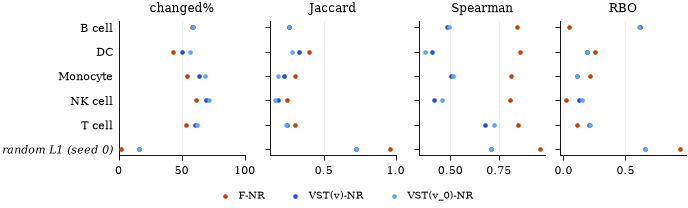

saved -> tables/aifi/summary_L1_2000hvg.tex


In [9]:
for LEVEL, (table, rows, control) in SUMMARY.items():
    plots.summary_figure(table, rows=rows, control=control,
                         path=FIG / f"summary_L{LEVEL + 1}_{N_TOP}hvg.pdf")
    plots.summary_latex(table, path=TEX / f"summary_L{LEVEL + 1}_{N_TOP}hvg.tex", control=control,
                        caption=(rf"Node-vs-root selection agreement at the top-{N_TOP}, median "
                                 rf"[min, max] over the internal nodes of "
                                 rf"\texttt{{{DS.label_cols[LEVEL]}}}."),
                        label=f"tab:hvg-summary-{DATASET}-L{LEVEL + 1}")

**Storage:** one `.npz` per score vector, one row per comparison.

In [10]:
display(scorer.store.catalog()[["method", "node", "cut", "loess_from", "n_cells", "n_classes"]])
display(scorer.store.metrics()[["key", "a_node", "b_node", "a_cut", "b_cut",
                                *plots.STAT_NAMES]].round(3))

,method,node,cut,loess_from,n_cells,n_classes
score_id,,,,,,
f_stat-t-cell-children-40d6ce5d,f_stat,T cell,children,None,1150345,10.0
f_stat-root-leaves-9041b350,f_stat,root,leaves,None,1821725,71.0
kw-t-cell-children-5e99824b,kw,T cell,children,None,1150345,10.0
vst-t-cell-local-de93a356,vst,T cell,None,None,1150345,NaN
vst-root-local-87c5cd1d,vst,root,None,None,1821725,NaN
vst-t-cell-root-2c5a3783,vst,T cell,None,root,1150345,NaN
f_stat-treg-children-aa4eec09,f_stat,Treg,children,None,39087,6.0
vst-treg-local-69658287,vst,Treg,None,None,39087,NaN
vst-treg-root-99aaf36c,vst,Treg,None,root,39087,NaN


,key,a_node,b_node,a_cut,b_cut,changed%,Jaccard,Spearman,Kendall,RBO
0,VST(v)-NR,Treg,root,NaN,NaN,70.40,0.174,0.286,0.245,0.053
1,VST(v_0)-NR,Treg,root,NaN,NaN,70.65,0.172,0.323,0.299,0.062
2,F-NR,Treg,root,children,leaves,56.45,0.278,0.803,0.636,0.128
3,F-NN,Monocyte,NK cell,children,children,65.50,0.208,0.789,0.614,0.031
4,VST(v_0)-NN,Monocyte,NK cell,NaN,NaN,72.25,0.161,0.556,0.474,0.089
5,F-NN,Naive CD4 T cell,Naive CD8 T cell,children,children,59.05,0.257,0.757,0.583,0.716
6,VST(v_0)-NN,Naive CD4 T cell,Naive CD8 T cell,NaN,NaN,50.65,0.328,0.696,0.650,0.462
7,F-CL,root,root,children,leaves,18.50,0.688,0.977,0.890,0.482
8,F-CL,T cell,T cell,children,leaves,6.40,0.880,0.987,0.927,0.720
9,F-NR,B cell,root,children,leaves,58.60,0.261,0.844,0.675,0.048


Downstream performance
----------------------

**reselect** recomputes the HVGs at every node, **fixed_global** reuses the root selection everywhere.

In [ ]:
HVG_METHODS = ("f_statistic", "seurat_v3") + (("kruskal_wallis",) if KW else ())
BUDGETS     = (300, 2000)
BACKENDS    = ("logit", "lgbm")   # runs.BACKEND_PARAMS define the hyperparameters
SPLIT       = dict(test_frac=0.20, seed=0, subsample=None)
GENE_BLOCK  = None   # bounds memory of one HVG pass, None -> default.

trained = [run
           for backend in BACKENDS
           for run in runs.run_variants(
               adata, DATASET, DS.label_cols, DS.config_path,
               [(hvg, n) for hvg in HVG_METHODS for n in BUDGETS], root="runs",
               backend=backend, backend_params=runs.BACKEND_PARAMS[backend],
               hvg_params={"gene_block": GENE_BLOCK} if GENE_BLOCK else None, **SPLIT)]
print([run.tag for run in trained] or "nothing requested")

Re-scoring saved runs
---------------------

In [ ]:
REFRESH_TAGS = None   # runs to (re)score, None -> every trained run

refreshed = runs.refresh_runs(adata, DATASET, DS.label_cols, root="runs", tags=REFRESH_TAGS)

for run in refreshed:
    display(run.read("scores").round(4))
    report.breakdown_figure(
        [(f"{LEVELS[by + 1]} accuracy by true {LEVELS[by]}",
          run.read(f"breakdown_{LEVELS[by + 1]}_by_{LEVELS[by]}")) for by in range(len(LEVELS) - 1)],
        path=FIG / f"{run.tag}_breakdown.pdf")

All runs
--------

In [ ]:
all_runs = report.runs_table("runs")
report.runs_figure(all_runs, "accuracy", path=Path("figures") / "runs_accuracy.pdf")
report.runs_figure(all_runs, "macro_f1", path=Path("figures") / "runs_macrof1.pdf")
print(report.runs_latex(all_runs, "accuracy", path=Path("tables") / "runs_accuracy.tex",
                        caption=r"Per-level accuracy of the reselect arm and its gain over "
                                r"fixed\_global, per dataset, HVG method, budget and backend.",
                        label="tab:runs-accuracy"))

In [13]:
# Per-dataset model comparison: rows = HVG method x budget, columns = level x arm.
for ds in sorted(all_runs["dataset"].unique()):
    for short, metric in (("accuracy", "accuracy"), ("macrof1", "macro_f1")):
        report.comparison_latex(
            all_runs, ds, metric, path=Path("tables") / ds / f"model_comparison_{short}.tex",
            caption=(rf"{ds}: {metric.replace('_', '-')} per taxonomy level, per-node reselection "
                     r"vs a single fixed\_global set. Bold = better arm of the pair, "
                     r"underline = best for the level."),
            label=f"tab:comparison-{ds}-{short}")

display(report.comparison_frame(all_runs, DATASET, "accuracy").round(4))

saved -> tables/aifi/model_comparison_accuracy.tex
saved -> tables/aifi/model_comparison_macrof1.tex
saved -> tables/hao/model_comparison_accuracy.tex
saved -> tables/hao/model_comparison_macrof1.tex


L1                    L2               \
                           reselect fixed_global reselect fixed_global   
hvg                  n_hvg                                               
f_statistic          300     0.9968       0.9970   0.9313       0.9172   
                     2000    0.9973       0.9973   0.9490       0.9479   
seurat_v3_shareloess 300     0.9937       0.9937   0.9105       0.7852   
                     2000    0.9973       0.9973   0.9460       0.9458   

                                 L3               
                           reselect fixed_global  
hvg                  n_hvg                        
f_statistic          300     0.8566       0.8062  
                     2000    0.8791       0.8693  
seurat_v3_shareloess 300     0.8194       0.6660  
                     2000    0.8648       0.8675

Node models
-----------

Same gene selections under each backend.

In [ ]:
# None -> the dataset-wide comparison only; a (method, budget) pair also zooms on that one
# configuration, where the per-node gain of each backend can be read side by side.
ZOOM = ("seurat_v3_shareloess", 300)

if all_runs.loc[all_runs["dataset"] == DATASET, "backend"].nunique() < 2:
    print(f"{DATASET}: one backend on disk, nothing to compare")
else:
    for short, metric in (("accuracy", "accuracy"), ("macrof1", "macro_f1")):
        report.backend_figure(all_runs, DATASET, metric, path=FIG / f"backend_{short}.pdf")
        report.backend_latex(
            all_runs, DATASET, metric, path=TEX / f"backend_{short}.tex",
            caption=(rf"{DATASET}: {metric.replace('_', '-')} of the reselect arm per node model, "
                     r"for identical gene selections. $\Delta$ is relative to logit."),
            label=f"tab:backend-{DATASET}-{short}")

    if ZOOM:
        HVG, N_HVG_ZOOM = ZOOM
        one = all_runs[(all_runs["dataset"] == DATASET) & (all_runs["hvg"] == HVG)
                       & (all_runs["n_hvg"] == N_HVG_ZOOM)]
        stem = f"{HVG}_{N_HVG_ZOOM:04d}"
        report.runs_figure(one, "accuracy", path=FIG / f"{stem}_backend_gain.pdf")
        report.gain_figure(
            [runs.Run("runs", DATASET, f"{stem}hvg_{backend}") for backend in BACKENDS],
            LEVELS, labels=list(BACKENDS), path=FIG / f"{stem}_backend_gain_by_node.pdf")
        print(report.backend_latex(
            one, DATASET, "accuracy", path=TEX / f"{stem}_backend.tex",
            caption=(rf"{DATASET}, {HVG.replace('_', chr(92) + '_')} @{N_HVG_ZOOM}: reselect-arm "
                     r"accuracy per node model. $\Delta$ vs logit."),
            label=f"tab:backend-{DATASET}-{HVG}-{N_HVG_ZOOM}"))

Across configurations
---------------------

Same nodes read across every (HVG method $\times$ node model) at one gene budget.

In [ ]:
GLOBAL_N_HVG = 300

configs = runs.configurations("runs", DATASET, GLOBAL_N_HVG)
labels = [report.config_label(run.tag) for run in configs]
stem = f"all_configs_{GLOBAL_N_HVG:04d}hvg_breakdown"
print(f"{len(configs)} configurations: " + ", ".join(labels))

report.config_breakdown_figure(configs, LEVELS, labels, path=FIG / f"{stem}.pdf",
                               title=report.config_title(DATASET, configs, GLOBAL_N_HVG))

verdicts = report.consistency_frame(configs, LEVELS, labels)
verdicts.to_csv(TEX / f"{stem}.csv", index=False)
print(f"saved -> {TEX / f'{stem}.csv'}")
display(verdicts[["split", "node", "verdict", "mean", "between_method", "within_method", *labels]]
        .round(4))
print(verdicts["verdict"].value_counts().to_string())

Repeated splits
---------------

Monte Carlo cross-validation of one configuration, under `runs_repeats/` separately (not to impact the cross-run tables).

Note: expensive, one full comparison per seed, nothing shared.

In [ ]:
REPEAT       = None        # (method, budget) pair e.g. ("seurat_v3", 300), None -> skip
REPEAT_SEEDS = range(10)   # seeds to use for repeats

if REPEAT:
    repeats = runs.run_repeats(adata, DATASET, DS.label_cols, DS.config_path, *REPEAT,
                               seeds=REPEAT_SEEDS, root="runs_repeats", backend=BACKENDS[0],
                               backend_params=runs.BACKEND_PARAMS[BACKENDS[0]],
                               test_frac=0.20, subsample=None)
    base = runs.config_tag(repeats[0].dir / "config.yml")
    stem = f"{base}_repeats{len(repeats)}"

    for metric in ("accuracy", "macro_f1"):
        print(f"\n{metric} over {len(repeats)} splits:")
        print(report.repeat_levels(repeats, metric).round(4).to_string())
        report.repeat_levels_latex(
            repeats, metric, path=TEX / f"{stem}_{metric}.tex",
            caption=(rf"{DATASET}, \texttt{{{base.replace('_', chr(92) + '_')}}}: "
                     rf"{metric.replace('_', '-')} over {len(repeats)} stratified 80/20 splits, "
                     r"mean $\pm$ s.d. $\Delta$ = reselect $-$ fixed\_global."),
            label=f"tab:repeats-{DATASET}-{metric}")

    report.repeat_breakdown_figure(repeats, LEVELS, path=FIG / f"{stem}_breakdown.pdf")